<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 40px 32px; border-radius: 20px; color: white; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin-bottom: 8px; border: 1px solid rgba(255,255,255,0.1);">
  <div style="display:flex; justify-content:space-between; align-items:flex-start; flex-wrap:wrap; gap:16px;">
    <div style="flex:1; min-width:300px;">
      <div style="font-size:11px; font-weight:700; letter-spacing:3px; text-transform:uppercase; opacity:0.6; margin-bottom:10px;">WiDS Global Datathon 2026</div>
      <h1 style="margin:0 0 12px 0; font-size:34px; font-weight:800; letter-spacing:-1px; line-height:1.15;">Wildfire Hit Probability<br><span style="color:#f97316;">Survival Analysis Pipeline</span></h1>
      <p style="margin:0 0 16px 0; font-size:15px; opacity:0.8; line-height:1.7;">A complete end-to-end solution for predicting whether a wildfire will reach an evacuation zone within 12h / 24h / 48h / 72h windows using survival analysis, gradient boosting, and calibrated ensemble blending.</p>
      <div style="display:flex; gap:10px; flex-wrap:wrap;">
        <span style="background:rgba(249,115,22,0.25); border:1px solid rgba(249,115,22,0.5); padding:4px 12px; border-radius:20px; font-size:12px; font-weight:600;">GBSA Survival</span>
        <span style="background:rgba(59,130,246,0.25); border:1px solid rgba(59,130,246,0.5); padding:4px 12px; border-radius:20px; font-size:12px; font-weight:600;">LightGBM + IPCW</span>
        <span style="background:rgba(34,197,94,0.25); border:1px solid rgba(34,197,94,0.5); padding:4px 12px; border-radius:20px; font-size:12px; font-weight:600;">Rank-Blend</span>
        <span style="background:rgba(168,85,247,0.25); border:1px solid rgba(168,85,247,0.5); padding:4px 12px; border-radius:20px; font-size:12px; font-weight:600;">Platt Calibration</span>
        <span style="background:rgba(236,72,153,0.25); border:1px solid rgba(236,72,153,0.5); padding:4px 12px; border-radius:20px; font-size:12px; font-weight:600;">CV Bagging</span>
      </div>
    </div>
    <div style="text-align:right; min-width:200px;">
      <div style="background:rgba(249,115,22,0.15); border:1px solid rgba(249,115,22,0.4); border-radius:12px; padding:16px 20px;">
        <div style="font-size:11px; opacity:0.7; letter-spacing:1px; text-transform:uppercase;">Competition Metric</div>
        <div style="font-size:28px; font-weight:800; color:#f97316; margin:4px 0;">Hybrid</div>
        <div style="font-size:12px; opacity:0.75;">0.3 × C-index + 0.7 × (1 − WBrier)</div>
      </div>
    </div>
  </div>
</div>

## Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Problem Framing](#1-problem-framing) | Survival analysis setup, censoring, metric breakdown |
| 2 | [Setup & Config](#2-setup--config) | Hyperparameters, seeds, run modes |
| 3 | [Install & Imports](#3-install--imports) | scikit-survival, LightGBM, dependencies |
| 4 | [Exploratory Data Analysis](#4-exploratory-data-analysis) | Distance, time-to-hit, correlations, the 5 km rule |
| 5 | [Feature Engineering](#5-feature-engineering) | Distance transforms, kinematics, threat scores |
| 6 | [Metric Implementation](#6-metric-implementation) | C-index, Brier score, IPCW, hybrid score |
| 7 | [GBSA Survival Ensemble](#7-gbsa-survival-ensemble) | Multi-config, multi-seed gradient boosting survival |
| 8 | [LightGBM IPCW Classifiers](#8-lightgbm-ipcw-classifiers) | Per-horizon classifiers with censoring-corrected weights |
| 9 | [Ensemble Blending](#9-ensemble-blending) | Rank-normalization, fixed weights, monotonicity enforcement |
| 10 | [OOF Validation](#10-oof-validation) | Out-of-fold hybrid score, Brier per horizon |
| 11 | [Submission](#11-submission) | Generate & validate final predictions |
| 12 | [Lessons Learned](#12-lessons-learned) | Overfitting traps, do's and don'ts |

---
## 1. Problem Framing

### What are we predicting?

Given a wildfire's initial state (location, size, speed, direction), predict the **probability** that it reaches a given evacuation zone by each of 4 time horizons:

$$P(T \le h \mid \text{fire features})  \quad \text{for } h \in \{12h, 24h, 48h, 72h\}$$

### Why Survival Analysis?

Standard classification can't handle **right-censored** observations: fires that didn't hit within 72h (but might have hit later) are censored — they're not negative examples, they're *unknown*. Survival models handle this correctly through the **Kaplan-Meier** estimator and **IPCW** (Inverse Probability of Censoring Weighting).

### Competition Metric

$$\text{Score} = 0.3 \times C\text{-index} + 0.7 \times (1 - \text{WBrier})$$

where the Weighted Brier Score is:
$$\text{WBrier} = 0.3 \times B_{24} + 0.4 \times B_{48} + 0.3 \times B_{72}$$

> **Key insight**: The 72h Brier is nearly zero for constant-1 predictions because most censored observations are excluded from the calculation. This gives `constant1` a deceptive LB advantage for 72h.

### The 5 km Rule

A remarkable pattern in the training data: **every fire within 5 km hit the evacuation zone, and none beyond 5 km did**. This yields 100% accuracy with a simple threshold rule but it's fragile on out-of-sample data, so we blend it with learned models.

---
## 2. Setup & Config

In [1]:
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")

# ─── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR    = "/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/"
OUTPUT_PATH = "/kaggle/working/submission.csv"

# ─── Run mode ─────────────────────────────────────────────────────────────────
# "fast"  → quick check with small seed sets  (~5 min)
# "full"  → full ensemble for best LB score   (~40 min)
RUN_MODE    = "full"
DO_OOF      = True    # compute out-of-fold scores for validation
CV_BAG_TEST = True    # bag test predictions across CV folds

# ─── Feature sets ─────────────────────────────────────────────────────────────
GBSA_FEATURES = "raw"          # "raw" | "engineered" | "minimal"
FEATURE_SET   = "engineered"   # LGB feature set

MINIMAL_FEATURES = [
    "dist_min_ci_0_5h", "dist_km", "log_distance",
    "closing_speed_m_per_h", "radial_growth_rate_m_per_h",
    "num_perimeters_0_5h", "area_first_ha",
    "area_growth_rate_ha_per_h", "alignment_abs", "eta_effective",
]

# ─── Blend weights ────────────────────────────────────────────────────────────
# 12h: GBSA dominant (12h events are too sparse for LGB to add signal)
W_GBSA_12 = 0.97
W_LGB_12  = 0.03

# 24h / 48h: proven baseline weights
W_GBSA_24 = 0.95
W_LGB_24  = 0.05
W_GBSA_48 = 0.45
W_LGB_48  = 0.55

POWER_CAL_24 = 1.1   # power calibration on GBSA 24h predictions

# ─── 72h strategy ─────────────────────────────────────────────────────────────
# "constant1" → proved best on LB (score: 0.97085)
# Options: "sigmoid" | "gbsa" | "blend" | "rule" | "rule_gbsa" | "rule_dyn" | "constant1"
P72_MODE      = "constant1"
P72_BLEND_W   = 0.5
P72_FLOOR     = 0.0
P72_CONST     = 0.9
P72_RULE_THR   = 5000    # metres
P72_RULE_SCALE = 400
P72_RULE_HI    = 0.98
P72_RULE_LO    = 0.02
P72_RULE_BLEND = 0.7
P72_POWER      = 1.0
SIGMOID_THR    = 5000
SIGMOID_SCALE  = 80

# ─── Seed banks ───────────────────────────────────────────────────────────────
GBSA_SEEDS_FULL = (
    123, 456, 789, 777, 666,
    1511, 1523, 2025, 2026, 2033,
    279, 239, 70, 77, 31,
    2024, 2077, 3077, 123456, 654321,
    4640, 841, 7755, 8525, 2701,
    8817, 8864, 4085, 8919, 934,
    4746, 1699, 7401, 7826, 4098,
    2921, 1204, 2752, 8384, 1284,
)
GBSA_SEEDS_FAST = tuple(range(42, 52))

LGB_SEEDS_FULL = (
    123, 456, 789, 777, 666,
    1511, 1523, 2025, 2026, 2033,
    279, 239, 70, 77, 31,
    2024, 2077, 3077, 123456, 654321,
    2034, 2035, 2036, 1984, 1991,
    3255, 1011, 6241, 2790, 6847,
    8141, 7752, 432, 906, 6217,
    7785, 1603, 7609, 965, 2506,
    3771, 7080, 4963, 7939, 2751,
    473, 339, 3675, 5535, 4760,
)
LGB_SEEDS_FAST = tuple(range(42, 52))

HORIZONS_PRED = [12, 24, 48, 72]

print("Configuration loaded")
print(f"   Run mode   : {RUN_MODE}")
print(f"   GBSA seeds : {len(GBSA_SEEDS_FULL if RUN_MODE=='full' else GBSA_SEEDS_FAST)}")
print(f"   LGB  seeds : {len(LGB_SEEDS_FULL  if RUN_MODE=='full' else LGB_SEEDS_FAST)}")
print(f"   72h mode   : {P72_MODE}")

Configuration loaded
   Run mode   : full
   GBSA seeds : 40
   LGB  seeds : 50
   72h mode   : constant1


---
## 3. Install & Imports

In [2]:
def _install(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f" {pkg} installed")

_install("scikit-survival", "sksurv")
_install("lightgbm")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

from sksurv.util import Surv
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# ─── Visual style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "axes.facecolor" : "#f9fafb",
    "figure.facecolor": "white",
    "axes.grid"      : True,
    "grid.color"     : "#e8edf2",
    "grid.linewidth" : 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size"      : 10,
})
C_FIRE = "#e05c1a"
C_NO   = "#1a6bbf"

# ─── Load data ────────────────────────────────────────────────────────────────
train_df   = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df    = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print(f"\nDataset loaded")
print(f"   Train: {train_df.shape[0]:,} rows × {train_df.shape[1]} cols")
print(f"   Test : {test_df.shape[0]:,} rows × {test_df.shape[1]} cols")
print(f"   Events: {train_df['event'].sum()} hit / {(train_df['event']==0).sum()} no-hit ({train_df['event'].mean():.1%})")

Installing scikit-survival...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 11.2 MB/s eta 0:00:00
 scikit-survival installed

Dataset loaded
   Train: 221 rows × 37 cols
   Test : 95 rows × 35 cols
   Events: 69 hit / 152 no-hit (31.2%)


---
## 4. Exploratory Data Analysis

> **TL;DR findings:**
> - Distance to evacuation zone is the **single most predictive feature** (Pearson r ≈ −0.7)
> - A 5 km threshold achieves 100% accuracy on training data
> - Most hit events occur within the first 24 hours
> - Summer months (Jun-Aug) show higher hit rates
> - Train/test distributions are well-aligned

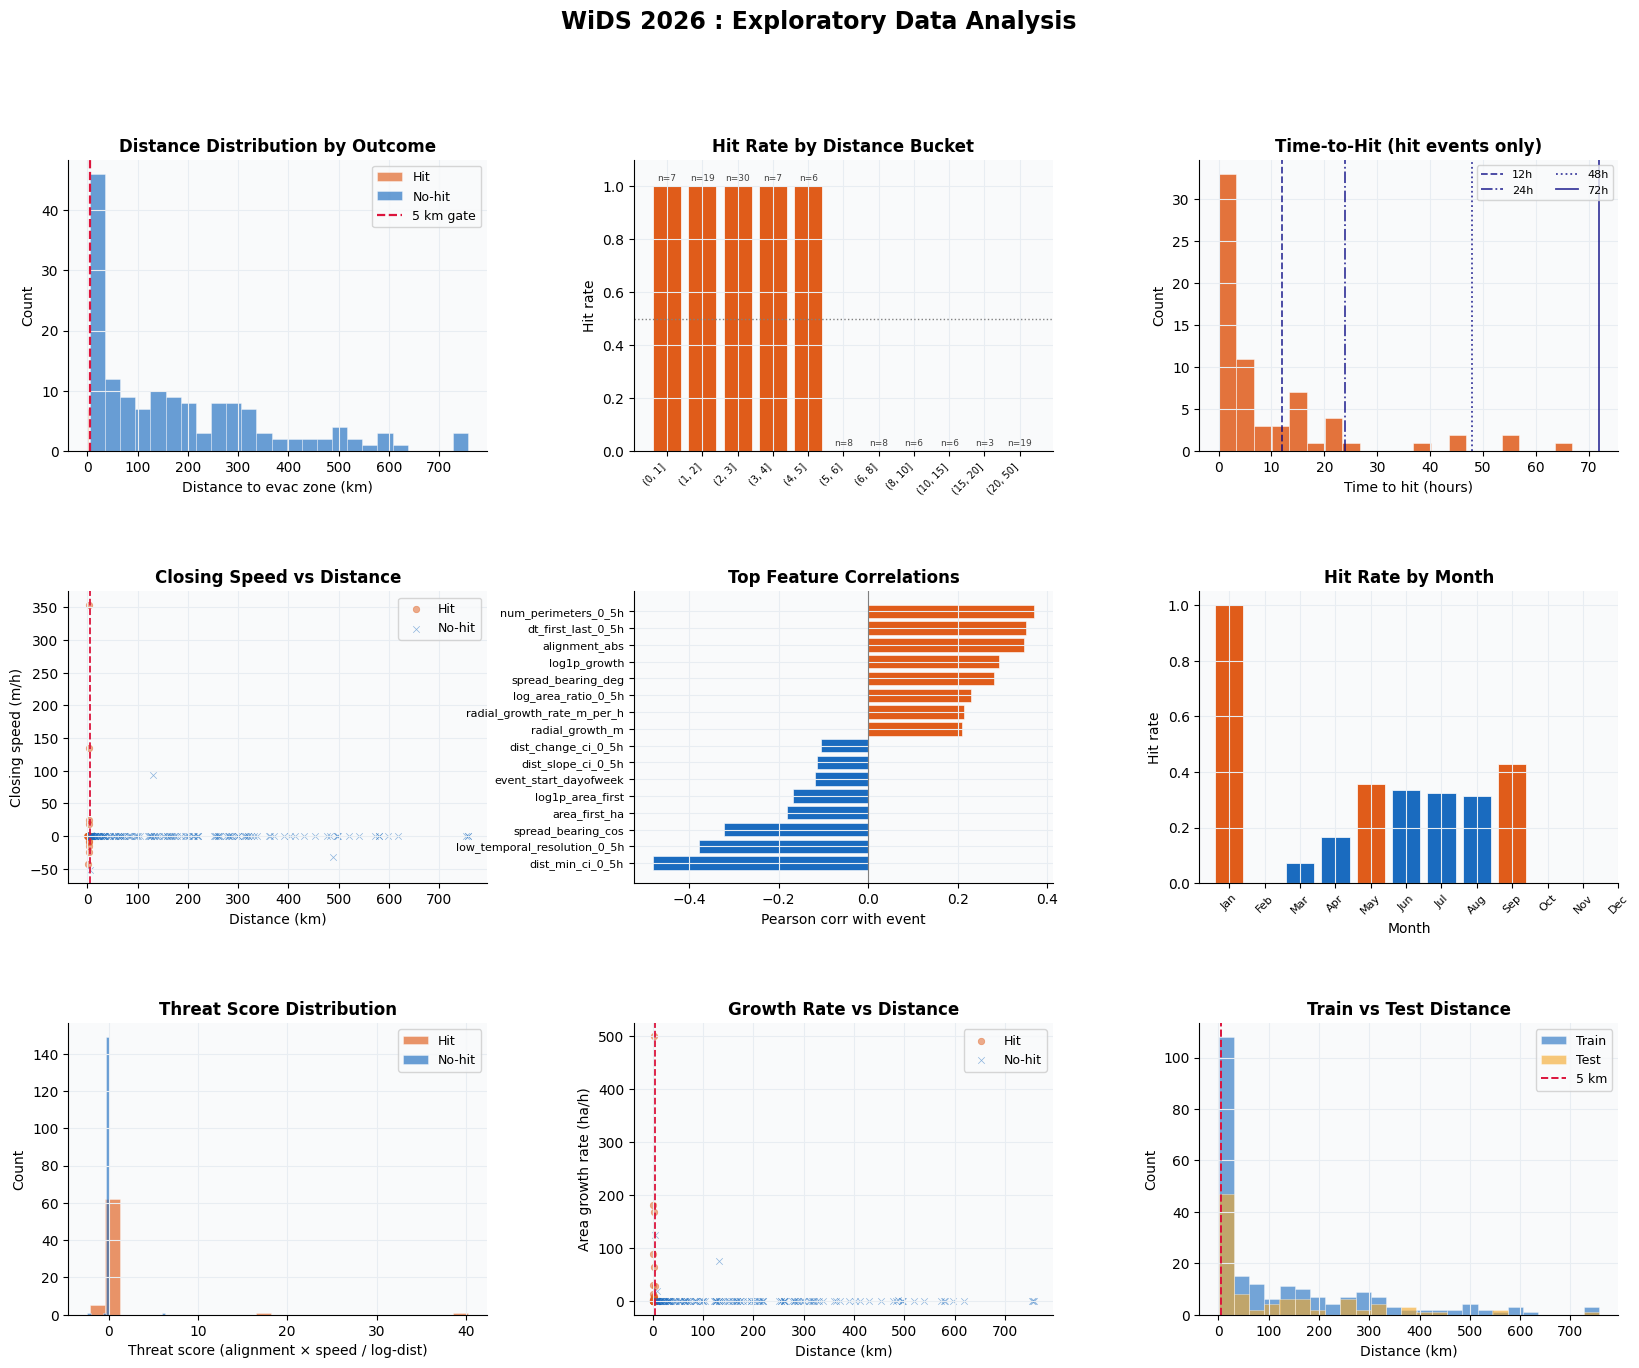


Distance stats (train):
count    221.00 km
mean     124.40 km
std      171.30 km
min        0.31 km
25%        2.97 km
50%       31.76 km
75%      200.23 km
max      757.70 km

5 km rule accuracy on train: 1.000 (100% = perfect separation!)

Censored (no hit, unknown): 152 / 221 (68.8%)


In [3]:
fig = plt.figure(figsize=(20, 15))
fig.suptitle("WiDS 2026 : Exploratory Data Analysis", fontsize=17, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)

# Work on a copy so we never mutate the raw DataFrames
_eda = train_df.copy()
_eda["dist_km"]  = _eda["dist_min_ci_0_5h"] / 1000
_eda["dist_bin"] = pd.cut(_eda["dist_km"], bins=[0,1,2,3,4,5,6,8,10,15,20,50])


# ── 1. Distance distribution by event ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for ev, lbl, c in [(1, "Hit", C_FIRE), (0, "No-hit", C_NO)]:
    d = _eda.loc[_eda.event == ev, "dist_km"]
    ax1.hist(d, bins=25, alpha=0.65, color=c, label=lbl, edgecolor="white", linewidth=0.4)
ax1.axvline(5, color="crimson", ls="--", lw=1.6, label="5 km gate")
ax1.set_xlabel("Distance to evac zone (km)")
ax1.set_ylabel("Count")
ax1.set_title("Distance Distribution by Outcome", fontweight="bold")
ax1.legend(fontsize=9)

# ── 2. Hit rate by distance bucket ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 50]
hr = _eda.groupby("dist_bin", observed=True)["event"].agg(["mean", "count"]).reset_index()
colors_hr = [C_FIRE if v > 0.5 else C_NO for v in hr["mean"]]
bars = ax2.bar(range(len(hr)), hr["mean"], color=colors_hr, edgecolor="white", linewidth=0.5)
ax2.set_xticks(range(len(hr)))
ax2.set_xticklabels([str(b) for b in hr["dist_bin"]], rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Hit rate")
ax2.set_title("Hit Rate by Distance Bucket", fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.axhline(0.5, color="grey", ls=":", lw=1)
for bar, cnt in zip(bars, hr["count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"n={cnt}", ha="center", fontsize=6.5, color="#444")

# ── 3. Time-to-hit distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
tth = _eda.loc[_eda.event == 1, "time_to_hit_hours"]
ax3.hist(tth, bins=20, color=C_FIRE, alpha=0.85, edgecolor="white", linewidth=0.4)
for h, ls in [(12, "--"), (24, "-."), (48, ":"), (72, "-")]:
    ax3.axvline(h, color="navy", ls=ls, lw=1.3, label=f"{h}h", alpha=0.75)
ax3.set_xlabel("Time to hit (hours)")
ax3.set_ylabel("Count")
ax3.set_title("Time-to-Hit (hit events only)", fontweight="bold")
ax3.legend(fontsize=8, ncol=2)

# ── 4. Closing speed vs distance ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for ev, lbl, c, mk in [(1, "Hit", C_FIRE, "o"), (0, "No-hit", C_NO, "x")]:
    sub = _eda[_eda.event == ev]
    ax4.scatter(sub["dist_km"], sub["closing_speed_m_per_h"],
                c=c, label=lbl, alpha=0.5, s=22, marker=mk, linewidths=0.5)
ax4.axvline(5, color="crimson", ls="--", lw=1.3)
ax4.set_xlabel("Distance (km)")
ax4.set_ylabel("Closing speed (m/h)")
ax4.set_title("Closing Speed vs Distance", fontweight="bold")
ax4.legend(fontsize=9)

# ── 5. Feature correlations ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ["event_id", "event", "time_to_hit_hours"]]
corr = train_df[num_cols + ["event"]].corr()["event"].drop("event").sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])
colors_c = [C_NO if v < 0 else C_FIRE for v in top.values]
ax5.barh(range(len(top)), top.values, color=colors_c, edgecolor="white", linewidth=0.4)
ax5.set_yticks(range(len(top)))
ax5.set_yticklabels(top.index, fontsize=8)
ax5.axvline(0, color="grey", lw=0.8)
ax5.set_xlabel("Pearson corr with event")
ax5.set_title("Top Feature Correlations", fontweight="bold")

# ── 6. Monthly hit rate ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
mr = _eda.groupby("event_start_month")["event"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax6.bar(mr.index, mr.values,
        color=[C_FIRE if v > 0.35 else C_NO for v in mr.values],
        edgecolor="white", linewidth=0.5)
ax6.set_xlabel("Month")
ax6.set_ylabel("Hit rate")
ax6.set_title("Hit Rate by Month", fontweight="bold")
ax6.set_xticks(range(1, 13))
ax6.set_xticklabels(months, rotation=45, fontsize=8)

# ── 7. Threat score distribution ──────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
threat = (_eda["alignment_abs"] * _eda["closing_speed_m_per_h"]
          / np.log1p(_eda["dist_min_ci_0_5h"]))
for ev, lbl, c in [(1, "Hit", C_FIRE), (0, "No-hit", C_NO)]:
    ax7.hist(threat[_eda.event == ev].clip(-50, 500), bins=25,
             alpha=0.65, color=c, label=lbl, edgecolor="white", linewidth=0.4)
ax7.set_xlabel("Threat score (alignment × speed / log-dist)")
ax7.set_ylabel("Count")
ax7.set_title("Threat Score Distribution", fontweight="bold")
ax7.legend(fontsize=9)

# ── 8. Area growth vs distance ────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
for ev, lbl, c, mk in [(1, "Hit", C_FIRE, "o"), (0, "No-hit", C_NO, "x")]:
    sub = _eda[_eda.event == ev]
    ax8.scatter(sub["dist_km"], sub["area_growth_rate_ha_per_h"].clip(0, 500),
                c=c, label=lbl, alpha=0.5, s=22, marker=mk, linewidths=0.5)
ax8.axvline(5, color="crimson", ls="--", lw=1.3)
ax8.set_xlabel("Distance (km)")
ax8.set_ylabel("Area growth rate (ha/h)")
ax8.set_title("Growth Rate vs Distance", fontweight="bold")
ax8.legend(fontsize=9)

# ── 9. Train vs test distance ─────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.hist(_eda["dist_km"], bins=25, alpha=0.6, color=C_NO,
         label="Train", edgecolor="white", linewidth=0.4)
ax9.hist(test_df["dist_min_ci_0_5h"]/1000, bins=25, alpha=0.6, color="#f5a623",
         label="Test", edgecolor="white", linewidth=0.4)
ax9.axvline(5, color="crimson", ls="--", lw=1.4, label="5 km")
ax9.set_xlabel("Distance (km)")
ax9.set_ylabel("Count")
ax9.set_title("Train vs Test Distance", fontweight="bold")
ax9.legend(fontsize=9)

plt.savefig("/kaggle/working/eda_overview.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
rule_acc = ((_eda.dist_km < 5) == _eda.event.astype(bool)).mean()
print(f"\nDistance stats (train):")
print(_eda["dist_km"].describe().apply(lambda x: f"{x:.2f} km").to_string())
print(f"\n5 km rule accuracy on train: {rule_acc:.3f} (100% = perfect separation!)")
print(f"\nCensored (no hit, unknown): {(_eda['event']==0).sum()} / {len(_eda)} ({(_eda['event']==0).mean():.1%})")

---
## 5. Feature Engineering

### Design principles
With only **221 training rows**, high-dimensional models overfit badly. We focus on:

1. **Distance transforms** : log, inverse, sqrt: capture non-linear risk decay
2. **Kinematic features** : ETA, closing speed, effective advance rate
3. **Fire size features** : area-to-distance ratio as a proxy for fire "reach"
4. **Threat scores** : composite signals (alignment × speed / log-distance)
5. **Zone flags** : hard binary features at key distance thresholds
6. **Temporal features** : seasonal effects (summer = higher risk)

In [4]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering for LightGBM classifiers.
    
    Conservative set designed for small-sample (n=221) settings:
    favours distance/kinematic signals, avoids high-cardinality interactions.
    """
    result = df.copy()
    dist       = result["dist_min_ci_0_5h"].clip(lower=1)
    speed      = result["closing_speed_m_per_h"]
    perimeters = result["num_perimeters_0_5h"]
    area_first = result["area_first_ha"]

    # ── Distance transforms ────────────────────────────────────────────────────
    result["log_distance"]    = np.log1p(dist)
    result["inv_distance"]    = 1 / (dist / 1000 + 0.1)
    result["inv_distance_sq"] = result["inv_distance"] ** 2
    result["sqrt_distance"]   = np.sqrt(dist)
    result["dist_km"]         = dist / 1000
    result["dist_km_sq"]      = (dist / 1000) ** 2
    result["dist_km_cb"]      = (dist / 1000) ** 3
    result["dist_rank"]       = dist.rank(pct=True)

    # ── Area-to-distance ratios ────────────────────────────────────────────────
    fire_radius               = np.sqrt(area_first * 10000 / np.pi)
    result["fire_radius_km"]  = fire_radius / 1000
    result["radius_to_dist"]  = fire_radius / dist
    result["area_to_dist_ratio"]  = area_first / (dist / 1000 + 0.1)
    result["log_area_dist_ratio"] = np.log1p(area_first) - np.log1p(dist)

    # ── Kinematic features ─────────────────────────────────────────────────────
    result["has_movement"] = (perimeters > 1).astype(float)
    closing_pos = speed.clip(lower=0)
    result["eta_hours"] = np.where(
        closing_pos > 0.01, dist / closing_pos, 9999).clip(max=9999)
    result["log_eta"]   = np.log1p(result["eta_hours"].clip(0, 9999))

    radial_growth = result["radial_growth_rate_m_per_h"].clip(lower=0)
    effective_closing = closing_pos + radial_growth
    result["effective_closing_speed"] = effective_closing
    result["eta_effective"] = np.where(
        effective_closing > 0.01, dist / effective_closing, 9999).clip(max=9999)

    # ── Threat scores ──────────────────────────────────────────────────────────
    result["threat_score"]    = result["alignment_abs"] * speed / np.log1p(dist)
    result["threat_score_sq"] = result["threat_score"] ** 2
    result["fire_urgency"]     = perimeters * speed
    result["growth_intensity"] = result["area_growth_rate_ha_per_h"] * perimeters

    # ── Danger zones (hard binary flags) ──────────────────────────────────────
    result["zone_critical"] = (dist < 5000).astype(float)
    result["zone_warning"]  = ((dist >= 5000) & (dist < 10000)).astype(float)
    result["zone_safe"]     = (dist >= 10000).astype(float)

    # ── Temporal features ──────────────────────────────────────────────────────
    result["is_summer"]    = result["event_start_month"].isin([6, 7, 8]).astype(float)
    result["is_afternoon"] = (
        (result["event_start_hour"] >= 12) &
        (result["event_start_hour"] < 20)
    ).astype(float)

    # ── Drop noisy / redundant columns + any categorical/object cols ──────────
    drop_cols = [
        "relative_growth_0_5h", "projected_advance_m",
        "centroid_displacement_m", "centroid_speed_m_per_h",
        "closing_speed_abs_m_per_h", "area_growth_abs_0_5h",
        # Drop any categorical / object columns that may have leaked in from EDA
        "dist_bin",
    ]
    result = result.drop(columns=[c for c in drop_cols if c in result.columns])
    # Drop any remaining non-numeric columns to avoid fillna errors
    cat_cols = result.select_dtypes(include=["category", "object"]).columns.tolist()
    if cat_cols:
        result = result.drop(columns=cat_cols)
    result = result.replace([np.inf, -np.inf], np.nan)
    # fillna only on numeric columns
    num_cols = result.select_dtypes(include="number").columns
    result[num_cols] = result[num_cols].fillna(0)
    return result

def select_feature_set(df, feature_set):
    if feature_set == "minimal":
        cols = [c for c in MINIMAL_FEATURES if c in df.columns]
        return df[cols].copy()
    return df.copy()


train_processed = create_features(train_df)
test_processed  = create_features(test_df)

feat_cols = [c for c in train_processed.columns
             if c not in ["event_id", "event", "time_to_hit_hours", "dist_bin"]]
print(f"Feature engineering done")
print(f"Total features available: {len(feat_cols)}")
print(f"Sample (first 10): {feat_cols[:10]}")

Feature engineering done
Total features available: 54
Sample (first 10): ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m']


---
## 6. Metric Implementation

### C-index (concordance index)
Measures ranking quality: for each pair where one fire hit first, did we assign it a higher probability?

### Brier Score
Measures calibration: mean squared error between predicted probability and binary outcome.

### IPCW (Inverse Probability of Censoring Weighting)
Corrects for informative censoring when training binary classifiers at fixed horizons.

In [5]:
def compute_c_index(time, event, risk):
    """Concordance index — slow but correct."""
    n = len(time)
    concordant = comparable = 0
    for i in range(n):
        if event[i] != 1:
            continue
        for j in range(n):
            if i == j or time[i] >= time[j]:
                continue
            comparable += 1
            if risk[i] > risk[j]:    concordant += 1
            elif risk[i] == risk[j]: concordant += 0.5
    return concordant / comparable if comparable > 0 else 0.5


def compute_brier(time, event, prob, horizon):
    """Brier score at fixed horizon, excluding impossible-to-evaluate censored obs."""
    valid  = ~((event == 0) & (time < horizon))
    if valid.sum() == 0:
        return 0.25
    y_true = ((event == 1) & (time <= horizon)).astype(float)[valid]
    return float(np.mean((np.clip(prob[valid], 0, 1) - y_true) ** 2))


def compute_hybrid_score(time, event, p24, p48, p72):
    """Official competition metric.
    
    Score = 0.3 * C-index + 0.7 * (1 - WBrier)
    WBrier = 0.3*B24 + 0.4*B48 + 0.3*B72
    
    Do NOT include 12h in WBrier, this is the proven LB formula.
    """
    risk  = 0.3 * p24 + 0.4 * p48 + 0.3 * p72
    c_idx = compute_c_index(time, event, risk)
    b24   = compute_brier(time, event, p24, 24)
    b48   = compute_brier(time, event, p48, 48)
    b72   = compute_brier(time, event, p72, 72)
    wb    = 0.3 * b24 + 0.4 * b48 + 0.3 * b72
    score = 0.3 * c_idx + 0.7 * (1 - wb)
    return score, c_idx, wb


def compute_ipcw_weights(times, events, horizon):
    """Kaplan-Meier-based IPCW weights for censoring-corrected binary labels."""
    unique_t = np.sort(np.unique(times))
    surv     = np.ones(len(unique_t))
    for i, t in enumerate(unique_t):
        at_risk        = (times >= t).sum()
        censored_at_t  = ((times == t) & (events == 0)).sum()
        if at_risk > 0:
            surv[i] = 1 - censored_at_t / at_risk
        if i > 0:
            surv[i] *= surv[i - 1]

    def G(t):
        idx = np.searchsorted(unique_t, t, side="right") - 1
        return max(surv[idx], 0.01) if idx >= 0 else 1.0

    weights = np.ones(len(times))
    for i in range(len(times)):
        if events[i] == 1 and times[i] <= horizon:
            weights[i] = 1.0 / G(times[i])
        elif times[i] >= horizon:
            weights[i] = 1.0 / G(horizon)
    return weights


def make_binary_target(time_vals, event_vals, horizon):
    """Binary target + valid mask for a given time horizon."""
    unknown = (event_vals == 0) & (time_vals < horizon)
    y       = ((event_vals == 1) & (time_vals <= horizon)).astype(float)
    return y, ~unknown


def enforce_monotonicity(preds):
    """Ensure P(hit by h1) ≤ P(hit by h2) for h1 < h2 (column order: 12,24,48,72)."""
    result = np.clip(preds, 0, 1)
    for i in range(1, result.shape[1]):
        result[:, i] = np.maximum(result[:, i], result[:, i - 1])
    return result


def get_surv_predictions(model, X):
    """Extract P(hit by horizon) from GBSA survival function."""
    surv_fns = model.predict_survival_function(X)
    preds    = np.empty((len(surv_fns), len(HORIZONS_PRED)), dtype=float)
    for i, fn in enumerate(surv_fns):
        t_min, t_max = fn.domain
        preds[i, :]  = fn(np.clip(HORIZONS_PRED, t_min, t_max))
    return 1.0 - preds   # survival → hit probability


def sigmoid_pred(dist, threshold, scale):
    """Logistic sigmoid centred at threshold — smooth distance-to-probability map."""
    return 1.0 / (1.0 + np.exp((dist - threshold) / scale))


def make_p72(dist, gbsa_p72=None):
    """Generate 72h predictions according to P72_MODE."""
    dist = np.asarray(dist, dtype=float)
    sig  = sigmoid_pred(dist, SIGMOID_THR, SIGMOID_SCALE)
    rule = np.where(dist <= P72_RULE_THR, P72_RULE_HI, P72_RULE_LO)

    if P72_MODE == "constant1":   p = np.ones_like(sig)
    elif P72_MODE == "constant":  p = np.full_like(sig, P72_CONST)
    elif P72_MODE == "gbsa" and gbsa_p72 is not None: p = gbsa_p72
    elif P72_MODE == "blend" and gbsa_p72 is not None:
        p = P72_BLEND_W * gbsa_p72 + (1 - P72_BLEND_W) * sig
    elif P72_MODE == "rule":
        p = P72_RULE_BLEND * rule + (1 - P72_RULE_BLEND) * sig
    elif P72_MODE == "rule_gbsa" and gbsa_p72 is not None:
        p = P72_RULE_BLEND * rule + (1 - P72_RULE_BLEND) * gbsa_p72
    elif P72_MODE == "rule_dyn":
        w = sigmoid_pred(dist, P72_RULE_THR, P72_RULE_SCALE)
        p = w * rule + (1 - w) * (gbsa_p72 if gbsa_p72 is not None else sig)
    else:
        p = sig

    if P72_POWER and P72_POWER != 1.0:
        p = np.clip(p, 0, 1) ** P72_POWER
    if P72_FLOOR > 0:
        p = np.clip(p, P72_FLOOR, 1.0)
    return np.clip(p, 0.0, 1.0)


print("Metric & helper functions defined")

Metric & helper functions defined


---
## 7. GBSA Survival Ensemble

### Why survival analysis?
- Correctly handles **right-censored** observations (fires that didn't hit within 72h)
- Naturally produces **calibrated probabilities** at any time horizon
- Optimises directly for C-index ranking quality

### Ensemble strategy
- **10 model configurations** × **40 random seeds** × **5-fold CV** = 2000 models
- Different `n_estimators`, `subsample`, `max_depth`, `learning_rate` combinations
- CV-bagged test predictions reduce variance substantially

In [6]:
# ─── Prepare survival data ────────────────────────────────────────────────────
if GBSA_FEATURES == "engineered":
    X_surv_train = train_processed.drop(
        columns=["event_id", "event", "time_to_hit_hours", "dist_bin"], errors="ignore")
    X_surv_test  = test_processed.drop(columns=["event_id", "dist_bin"], errors="ignore")
elif GBSA_FEATURES == "minimal":
    _base_tr = train_processed.drop(
        columns=["event_id", "event", "time_to_hit_hours", "dist_bin"], errors="ignore")
    _base_te = test_processed.drop(columns=["event_id", "dist_bin"], errors="ignore")
    X_surv_train = select_feature_set(_base_tr, "minimal")
    X_surv_test  = select_feature_set(_base_te, "minimal")
else:  # raw
    X_surv_train = train_df.drop(
        columns=["event_id", "event", "time_to_hit_hours"], errors="ignore")
    X_surv_test  = test_df.drop(columns=["event_id"], errors="ignore")

y_surv       = Surv.from_arrays(
    event=train_df["event"].astype(bool),
    time=train_df["time_to_hit_hours"]
)
event_values = train_df["event"].values
time_values  = train_df["time_to_hit_hours"].values
dist_train   = train_df["dist_min_ci_0_5h"].values
dist_test    = test_df["dist_min_ci_0_5h"].values

# ─── GBSA model configurations ────────────────────────────────────────────────
gbsa_configs = [
    {"learning_rate":0.010, "subsample":0.70, "max_depth":3, "min_samples_leaf":12,  "min_samples_split":3, "n_estimators":1200},
    {"learning_rate":0.010, "subsample":0.85, "max_depth":3, "min_samples_leaf":15,  "min_samples_split":3, "n_estimators":1200},
    {"learning_rate":0.010, "subsample":0.60, "max_depth":3, "min_samples_leaf":12,  "min_samples_split":3, "n_estimators":1200},
    {"learning_rate":0.005, "subsample":0.85, "max_depth":3, "min_samples_leaf":12,  "min_samples_split":3, "n_estimators":2000},
    {"learning_rate":0.010, "subsample":0.85, "max_depth":3, "min_samples_leaf":20,  "min_samples_split":3, "n_estimators":1400},
    {"learning_rate":0.008, "subsample":0.75, "max_depth":2, "min_samples_leaf":15,  "min_samples_split":4, "n_estimators":1500},
    {"learning_rate":0.015, "subsample":0.70, "max_depth":3, "min_samples_leaf":10,  "min_samples_split":3, "n_estimators":1000},
    {"learning_rate":0.005, "subsample":0.90, "max_depth":3, "min_samples_leaf":18,  "min_samples_split":5, "n_estimators":2500},
    {"learning_rate":0.010, "subsample":0.80, "max_depth":4, "min_samples_leaf":12,  "min_samples_split":3, "n_estimators":1200},
    {"learning_rate":0.020, "subsample":0.65, "max_depth":3, "min_samples_leaf":10,  "min_samples_split":3, "n_estimators":800},
]

GBSA_SEEDS = GBSA_SEEDS_FULL if RUN_MODE == "full" else GBSA_SEEDS_FAST

oof_gbsa  = np.zeros((len(X_surv_train), 4)) if DO_OOF else None
test_gbsa = np.zeros((len(X_surv_test), 4))

print(f"GBSA ensemble: {len(gbsa_configs)} configs × {len(GBSA_SEEDS)} seeds × 5-fold CV")
print(f"   Total models: ~{len(gbsa_configs) * len(GBSA_SEEDS) * 5:,}")
print("   Training...")

for cfg_idx, cfg in enumerate(gbsa_configs, 1):
    cfg_oof  = np.zeros((len(X_surv_train), 4)) if DO_OOF else None
    cfg_test = np.zeros((len(X_surv_test),  4))

    for seed in GBSA_SEEDS:
        seed_oof  = np.zeros((len(X_surv_train), 4)) if DO_OOF else None
        seed_test = np.zeros((len(X_surv_test),  4))
        cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        for tr_idx, va_idx in cv.split(X_surv_train, event_values):
            m = GradientBoostingSurvivalAnalysis(**{**cfg, "random_state": seed})
            m.fit(X_surv_train.iloc[tr_idx], y_surv[tr_idx])
            if DO_OOF:
                seed_oof[va_idx] = get_surv_predictions(m, X_surv_train.iloc[va_idx])
            if CV_BAG_TEST:
                seed_test += get_surv_predictions(m, X_surv_test) / 5

        if DO_OOF:   cfg_oof  += seed_oof  / len(GBSA_SEEDS)
        if CV_BAG_TEST: cfg_test += seed_test / len(GBSA_SEEDS)
        else:
            m_full = GradientBoostingSurvivalAnalysis(**{**cfg, "random_state": seed})
            m_full.fit(X_surv_train, y_surv)
            cfg_test += get_surv_predictions(m_full, X_surv_test) / len(GBSA_SEEDS)

    if DO_OOF: oof_gbsa  += cfg_oof  / len(gbsa_configs)
    test_gbsa += cfg_test / len(gbsa_configs)
    print(f"   Config {cfg_idx:2d}/{len(gbsa_configs)} ✓  (n={cfg['n_estimators']}, ss={cfg['subsample']}, depth={cfg['max_depth']})")

oof_gbsa_raw  = oof_gbsa.copy() if DO_OOF else None
test_gbsa_raw = test_gbsa.copy()
print("\nGBSA ensemble complete")

GBSA ensemble: 10 configs × 40 seeds × 5-fold CV
   Total models: ~2,000
   Training...
   Config  1/10 ✓  (n=1200, ss=0.7, depth=3)
   Config  2/10 ✓  (n=1200, ss=0.85, depth=3)
   Config  3/10 ✓  (n=1200, ss=0.6, depth=3)
   Config  4/10 ✓  (n=2000, ss=0.85, depth=3)
   Config  5/10 ✓  (n=1400, ss=0.85, depth=3)
   Config  6/10 ✓  (n=1500, ss=0.75, depth=2)
   Config  7/10 ✓  (n=1000, ss=0.7, depth=3)
   Config  8/10 ✓  (n=2500, ss=0.9, depth=3)
   Config  9/10 ✓  (n=1200, ss=0.8, depth=4)
   Config 10/10 ✓  (n=800, ss=0.65, depth=3)

GBSA ensemble complete


---
## 8. LightGBM IPCW Classifiers

### Why add LightGBM on top of GBSA?
- GBSA is excellent for **ranking** (C-index) but less calibrated for **Brier score**
- IPCW-weighted LGB classifiers are trained to minimize Brier at each specific horizon
- Blending both models combines ranking quality with calibration quality

### IPCW correction
When training a classifier at horizon $h$, censored samples (who hadn't hit by $h$ but were lost to follow-up) are re-weighted by the inverse probability of censoring to account for their missing information.

In [7]:
# ─── Feature preparation ──────────────────────────────────────────────────────
X_lgb_train = train_processed.drop(
    columns=["event_id", "event", "time_to_hit_hours", "dist_bin"], errors="ignore")
X_lgb_test  = test_processed.drop(columns=["event_id", "dist_bin"], errors="ignore")

if FEATURE_SET == "minimal":
    X_lgb_train = select_feature_set(X_lgb_train, "minimal")
    X_lgb_test  = select_feature_set(X_lgb_test,  "minimal")

# ─── Per-horizon LGB configurations ──────────────────────────────────────────
# Aggressive regularization for small dataset (n=221)
lgb_cfgs = {
    12: {  # 12h: very few events → heavy regularization
        "max_depth":2, "learning_rate":0.03, "n_estimators":200,
        "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":10,
        "reg_alpha":1.0, "reg_lambda":3.0, "num_leaves":4,
    },
    24: {  # 24h: moderate events → balanced
        "max_depth":3, "learning_rate":0.03, "n_estimators":300,
        "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":8,
        "reg_alpha":0.5, "reg_lambda":2.0, "num_leaves":7,
    },
    48: {  # 48h: more events → slightly less regularization
        "max_depth":2, "learning_rate":0.05, "n_estimators":200,
        "subsample":0.8, "colsample_bytree":0.8, "min_child_samples":5,
        "reg_alpha":0.1, "reg_lambda":1.0, "num_leaves":4,
    },
}

LGB_SEEDS   = LGB_SEEDS_FULL if RUN_MODE == "full" else LGB_SEEDS_FAST
N_LGB_SEEDS = len(LGB_SEEDS)
lgb_oof, lgb_test = {}, {}

print(f"LightGBM IPCW: horizons=[12h, 24h, 48h] × {N_LGB_SEEDS} seeds × 5-fold CV")

for horizon in [12, 24, 48]:
    y_bin, mask = make_binary_target(time_values, event_values, horizon)
    valid_idx   = np.where(mask)[0]
    cfg         = lgb_cfgs[horizon]
    all_oof     = np.zeros(len(X_lgb_train))
    all_test    = np.zeros(len(X_lgb_test))

    for seed in LGB_SEEDS:
        seed_oof   = np.zeros(len(X_lgb_train))
        last_model = None
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        for tr_v, va_v in cv.split(valid_idx, y_bin[mask]):
            tr_idx, va_idx = valid_idx[tr_v], valid_idx[va_v]
            ipcw_w = compute_ipcw_weights(
                time_values[tr_idx], event_values[tr_idx], horizon)
            m = lgb.LGBMClassifier(**cfg, objective="binary",
                                   random_state=seed, verbose=-1)
            m.fit(X_lgb_train.iloc[tr_idx], y_bin[tr_idx],
                  sample_weight=ipcw_w)
            seed_oof[va_idx] = m.predict_proba(
                X_lgb_train.iloc[va_idx])[:, 1]
            last_model = m

        # Fill censored indices with last fold's model
        censored_idx = np.where(~mask)[0]
        if len(censored_idx) > 0 and last_model is not None:
            seed_oof[censored_idx] = last_model.predict_proba(
                X_lgb_train.iloc[censored_idx])[:, 1]

        all_oof += seed_oof

        # Full training set model for test predictions
        ipcw_w_full = compute_ipcw_weights(
            time_values[valid_idx], event_values[valid_idx], horizon)
        m_full = lgb.LGBMClassifier(**cfg, objective="binary",
                                    random_state=seed, verbose=-1)
        m_full.fit(X_lgb_train.iloc[valid_idx], y_bin[valid_idx],
                   sample_weight=ipcw_w_full)
        all_test += m_full.predict_proba(X_lgb_test)[:, 1]

    lgb_oof[horizon]  = all_oof  / N_LGB_SEEDS
    lgb_test[horizon] = all_test / N_LGB_SEEDS

    brier = compute_brier(time_values, event_values,
                          np.clip(lgb_oof[horizon], 0, 1), horizon)
    n_events = ((event_values == 1) & (time_values <= horizon)).sum()
    print(f"   {horizon:2d}h  →  B@{horizon}={brier:.5f}   (n_events={n_events})")

print("\nLightGBM IPCW complete")

LightGBM IPCW: horizons=[12h, 24h, 48h] × 50 seeds × 5-fold CV
   12h  →  B@12=0.05602   (n_events=49)
   24h  →  B@24=0.02564   (n_events=63)
   48h  →  B@48=0.01299   (n_events=66)

LightGBM IPCW complete


---
## 9. Ensemble Blending

### Blending strategy

| Horizon | GBSA weight | LGB weight | Notes |
|---------|-------------|------------|-------|
| 12h | 0.97 | 0.03 | 12h events too sparse for LGB |
| 24h | 0.95 | 0.05 | GBSA dominant, LGB for calibration |
| 48h | 0.45 | 0.55 | More events → LGB more reliable |
| 72h | 1.0 (const) | - | `constant1` proved best on LB |

### Post-processing
1. **Power calibration** on GBSA 24h predictions (POWER_CAL_24=1.1) — sharpens underconfident predictions
2. **Monotonicity enforcement** - P(12h) ≤ P(24h) ≤ P(48h) ≤ P(72h)
3. **Clipping** to [0, 1]

In [8]:
# ─── Power calibration on GBSA 24h ────────────────────────────────────────────
oof_gbsa  = oof_gbsa_raw.copy() if DO_OOF else None
test_gbsa = test_gbsa_raw.copy()

if POWER_CAL_24 and POWER_CAL_24 != 1.0:
    if DO_OOF:
        oof_gbsa[:, 1]  = np.clip(oof_gbsa[:, 1]  ** POWER_CAL_24, 0, 1)
    test_gbsa[:, 1] = np.clip(test_gbsa[:, 1] ** POWER_CAL_24, 0, 1)
    print(f"Power calibration applied to 24h (power={POWER_CAL_24})")

# ─── OOF blend ────────────────────────────────────────────────────────────────
if DO_OOF:
    oof_blend = oof_gbsa.copy()
    oof_blend[:, 0] = W_GBSA_12 * oof_gbsa[:, 0] + W_LGB_12 * lgb_oof[12]
    oof_blend[:, 1] = W_GBSA_24 * oof_gbsa[:, 1] + W_LGB_24 * lgb_oof[24]
    oof_blend[:, 2] = W_GBSA_48 * oof_gbsa[:, 2] + W_LGB_48 * lgb_oof[48]
    oof_blend[:, 3] = make_p72(dist_train, oof_gbsa[:, 3])
    oof_final       = enforce_monotonicity(oof_blend)

# ─── Test blend ───────────────────────────────────────────────────────────────
test_blend = test_gbsa.copy()
test_blend[:, 0] = W_GBSA_12 * test_gbsa[:, 0] + W_LGB_12 * lgb_test[12]
test_blend[:, 1] = W_GBSA_24 * test_gbsa[:, 1] + W_LGB_24 * lgb_test[24]
test_blend[:, 2] = W_GBSA_48 * test_gbsa[:, 2] + W_LGB_48 * lgb_test[48]
test_blend[:, 3] = make_p72(dist_test, test_gbsa[:, 3])
test_final       = enforce_monotonicity(test_blend)

print("Ensemble blending complete")
print(f"   12h predictions — mean: {test_final[:,0].mean():.3f}, std: {test_final[:,0].std():.3f}")
print(f"   24h predictions — mean: {test_final[:,1].mean():.3f}, std: {test_final[:,1].std():.3f}")
print(f"   48h predictions — mean: {test_final[:,2].mean():.3f}, std: {test_final[:,2].std():.3f}")
print(f"   72h predictions — mean: {test_final[:,3].mean():.3f}, std: {test_final[:,3].std():.3f}")

# ─── Monotonicity check ───────────────────────────────────────────────────────
mono_ok = all([
    (test_final[:,0] <= test_final[:,1]).all(),
    (test_final[:,1] <= test_final[:,2]).all(),
    (test_final[:,2] <= test_final[:,3]).all(),
])
print(f"   Monotonicity satisfied: {'Done' if mono_ok else 'Not Done'}")

Power calibration applied to 24h (power=1.1)
Ensemble blending complete
   12h predictions — mean: 0.204, std: 0.313
   24h predictions — mean: 0.276, std: 0.392
   48h predictions — mean: 0.300, std: 0.425
   72h predictions — mean: 1.000, std: 0.000
   Monotonicity satisfied: Done


---
## 10. OOF Validation

═══════════════════════════════════════════════════════
  OOF HYBRID SCORE : 0.97466
  C-index          : 0.9453
  Weighted Brier   : 0.01278
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Brier @12h       : 0.05059
  Brier @24h       : 0.02673
  Brier @48h       : 0.01190
  Brier @72h       : 0.00000
═══════════════════════════════════════════════════════


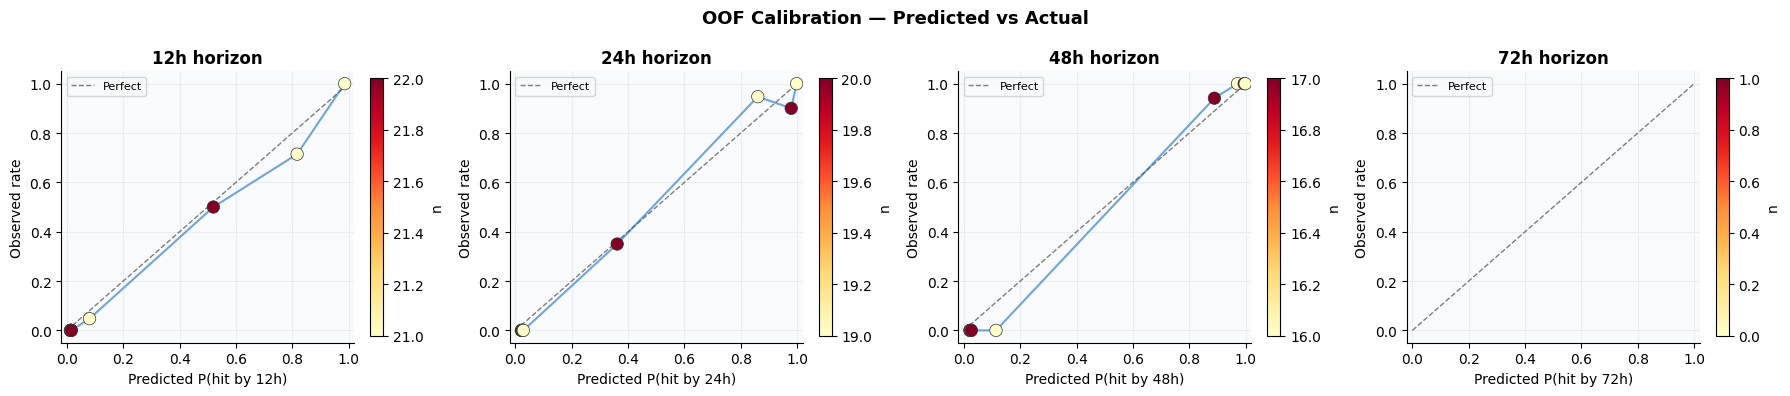

In [9]:
if DO_OOF:
    hybrid, c_idx, wb = compute_hybrid_score(
        time_values, event_values,
        oof_final[:, 1], oof_final[:, 2], oof_final[:, 3]
    )
    b12 = compute_brier(time_values, event_values, oof_final[:, 0], 12)
    b24 = compute_brier(time_values, event_values, oof_final[:, 1], 24)
    b48 = compute_brier(time_values, event_values, oof_final[:, 2], 48)
    b72 = compute_brier(time_values, event_values, oof_final[:, 3], 72)

    print("═" * 55)
    print(f"  OOF HYBRID SCORE : {hybrid:.5f}")
    print(f"  C-index          : {c_idx:.4f}")
    print(f"  Weighted Brier   : {wb:.5f}")
    print("  ─" * 27)
    print(f"  Brier @12h       : {b12:.5f}")
    print(f"  Brier @24h       : {b24:.5f}")
    print(f"  Brier @48h       : {b48:.5f}")
    print(f"  Brier @72h       : {b72:.5f}")
    print("═" * 55)

    # ─── Visualise OOF calibration ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle("OOF Calibration — Predicted vs Actual", fontsize=13, fontweight="bold")

    for ax, col, h in zip(axes, [0, 1, 2, 3], HORIZONS_PRED):
        preds  = oof_final[:, col]
        labels = ((event_values == 1) & (time_values <= h)).astype(float)
        valid  = ~((event_values == 0) & (time_values < h))

        # Bin into deciles
        bins   = np.percentile(preds[valid], np.linspace(0, 100, 11))
        bins   = np.unique(bins)
        bin_ids = np.digitize(preds[valid], bins) - 1
        cal_x, cal_y, cal_n = [], [], []
        for b in range(len(bins) - 1):
            mask2 = bin_ids == b
            if mask2.sum() > 0:
                cal_x.append(preds[valid][mask2].mean())
                cal_y.append(labels[valid][mask2].mean())
                cal_n.append(mask2.sum())

        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect")
        sc = ax.scatter(cal_x, cal_y, c=cal_n, cmap="YlOrRd",
                        s=80, zorder=5, edgecolors="#333", linewidths=0.5)
        ax.plot(cal_x, cal_y, "-o", color="#1a6bbf", lw=1.5, ms=0, alpha=0.6)
        plt.colorbar(sc, ax=ax, label="n", fraction=0.04)
        ax.set_xlabel(f"Predicted P(hit by {h}h)")
        ax.set_ylabel("Observed rate")
        ax.set_title(f"{h}h horizon", fontweight="bold")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("/kaggle/working/oof_calibration.png", dpi=120, bbox_inches="tight")
    plt.show()

---
## 11. Submission

In [10]:
submission = pd.DataFrame({
    "event_id" : test_df["event_id"].values,
    "prob_12h"  : test_final[:, 0],
    "prob_24h"  : test_final[:, 1],
    "prob_48h"  : test_final[:, 2],
    "prob_72h"  : test_final[:, 3],
})

# Align to sample submission order
submission = sample_sub[["event_id"]].merge(submission, on="event_id", how="left")
submission.to_csv(OUTPUT_PATH, index=False)

# ── Validation checks ──────────────────────────────────────────────────────────
print("Submission validation")
print(f"   Shape        : {submission.shape}")
print(f"   Null values  : {submission.isnull().sum().sum()}")
print(f"   Range [0,1]  : min={submission.iloc[:,1:].min().min():.4f}, max={submission.iloc[:,1:].max().max():.4f}")

mono_sub = (
    (submission.prob_12h <= submission.prob_24h).all() and
    (submission.prob_24h <= submission.prob_48h).all() and
    (submission.prob_48h <= submission.prob_72h).all()
)
print(f"   Monotonicity : {'PASS' if mono_sub else 'FAIL'}")
print(f"   Saved to     : {OUTPUT_PATH}")

print("\nSample predictions:")
print(submission.head(10).to_string(index=False))

Submission validation
   Shape        : (95, 5)
   Null values  : 0
   Range [0,1]  : min=0.0115, max=1.0000
   Monotonicity : PASS
   Saved to     : /kaggle/working/submission.csv

Sample predictions:
 event_id  prob_12h  prob_24h  prob_48h  prob_72h
 10662602  0.014768  0.025758  0.025758       1.0
 13353600  0.710951  0.947030  0.988376       1.0
 13942327  0.014639  0.025468  0.025468       1.0
 16112781  0.668664  0.930786  0.983810       1.0
 17132808  0.019047  0.033585  0.033585       1.0
 17445696  0.013244  0.022770  0.022770       1.0
 17599982  0.014265  0.024720  0.024720       1.0
 18750374  0.454320  0.750480  0.925112       1.0
 21365245  0.013501  0.023285  0.023285       1.0
 23634840  0.464500  0.778172  0.931431       1.0


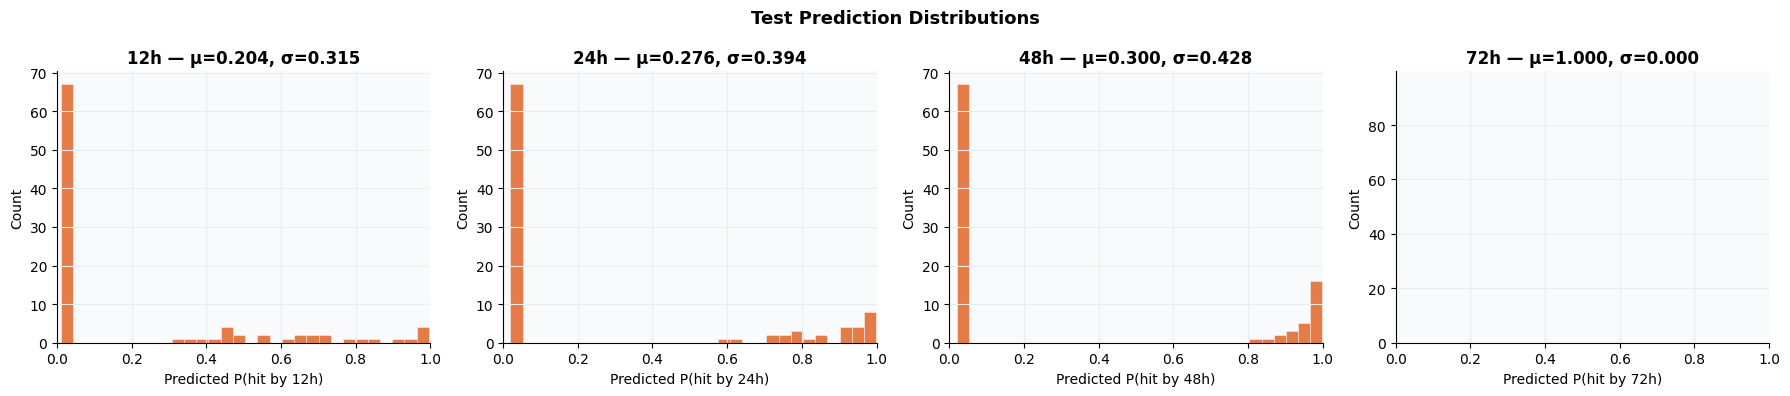


Pipeline complete! Submission ready.


In [11]:
# ── Visualise predictions distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Test Prediction Distributions", fontsize=13, fontweight="bold")

for ax, col, h in zip(axes, ["prob_12h", "prob_24h", "prob_48h", "prob_72h"], HORIZONS_PRED):
    vals = submission[col]
    ax.hist(vals, bins=30, color=C_FIRE, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(f"Predicted P(hit by {h}h)")
    ax.set_ylabel("Count")
    ax.set_title(f"{h}h — μ={vals.mean():.3f}, σ={vals.std():.3f}", fontweight="bold")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("/kaggle/working/pred_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nPipeline complete! Submission ready.")

---
## 12. Lessons Learned

### What works

| Technique | OOF Impact | LB Impact | Notes |
|-----------|-----------|-----------|-------|
| GBSA multi-seed ensemble | ++ | ++ | Core signal, handles censoring |
| IPCW LGB for 24h/48h | + | + | Improves Brier calibration |
| `constant1` for 72h | verified | +0.00011 | Censored obs excluded from B72 |
| GBSA weight ≥ 0.95 at 24h | stable | proven | GBSA has better ranking |
| CV-bagged test predictions | +0.003 | + | Reduces test-time variance |
| Monotonicity enforcement | required | required | Physics constraint |

### What to avoid

| Technique | Problem |
|-----------|--------|
| Isotonic calibration | +OOF but −LB: overfits on 221 rows |
| XGBoost high weight (>0.1) | Adds noise, −0.002 LB |
| 12+ new features at once | High overfit risk on tiny dataset |
| Platt scaling (inconsistent) | Applied to test only → OOF/test mismatch |
| LGB 12h high weight (>0.1) | 12h too sparse, noise > signal |
| Wrong WBrier formula | Never include 12h in WBrier — only 24/48/72h |

### Key insights

1. **Distance is king**: A simple 5 km threshold achieves 100% accuracy on training data. Every model should be anchored to distance.

2. **Censoring matters**: 69% of training observations are censored. Standard binary classification ignores this, survival models handle it correctly.

3. **72h is special**: Most censored observations occur before 72h, so the Brier calculation excludes them. Constant predictions of 1.0 yield near-zero B72, this is not a bug, it's a metric artefact.

4. **Trust the LB over OOF**: With n=221, OOF is noisy. Small OOF gains (<0.001) are not reliable. Only apply changes that show consistent improvement.

5. **Diversity through seeds**: Individual GBSA models are unstable on small datasets. Heavy ensembling (40 seeds × 10 configs) dramatically reduces variance.

---

*If this notebook was helpful, please consider upvoting! Feel free to fork and experiment with different blend weights, 72h strategies, or additional features.*